# Library Import

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from PIL import Image 
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import torch

In [2]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if using multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Set seed before any operations
set_seed(42)

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
class SiameseNetworkDataset(Dataset):
    def __init__(self, imageFolderDataset, transform=None):
        self.imageFolderDataset = imageFolderDataset    
        self.transform = transform
        
    def __getitem__(self, index):
        img0_tuple = random.choice(self.imageFolderDataset.imgs)

        # We need approximately 50% of images to be in the same class
        should_get_same_class = random.randint(0, 1) 
        if should_get_same_class:
            while True:
                # Look until the same class image is found
                img1_tuple = random.choice(self.imageFolderDataset.imgs) 
                if img0_tuple[1] == img1_tuple[1]:
                    break
        else:
            while True:
                # Look until a different class image is found
                img1_tuple = random.choice(self.imageFolderDataset.imgs) 
                if img0_tuple[1] != img1_tuple[1]:
                    break

        img0 = Image.open(img0_tuple[0])
        img1 = Image.open(img1_tuple[0])

        # Convert to RGB if image is in another format (e.g., RGBA)
        if img0.mode != 'RGB':
            img0 = img0.convert('RGB')
        if img1.mode != 'RGB':
            img1 = img1.convert('RGB')

        if self.transform is not None:
            img0 = self.transform(img0)
            img1 = self.transform(img1)
        
        # Return the images, similarity label (0 or 1), and the original class labels
        return img0, img1, torch.from_numpy(np.array([int(img1_tuple[1] != img0_tuple[1])], dtype=np.float32)), img0_tuple[1], img1_tuple[1]
    
    def __len__(self):
        return len(self.imageFolderDataset.imgs)

# Network

In [5]:
import torch
import torch.nn as nn
from torchvision.models import resnet18

class SiameseNetwork(nn.Module):
    def __init__(self):
        super(SiameseNetwork, self).__init__()
        
        # Using ResNet18 as the backbone with 3-channel input
        self.cnn1 = resnet18(pretrained=True)  # Using pretrained weights
        
        # Remove the original fully connected layer of ResNet18
        self.cnn1.fc = nn.Identity()
        
        # Setting up your custom Fully Connected Layers
        # ResNet18 outputs 512 features
        self.fc1 = nn.Sequential(
            nn.Linear(512, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, 256),
        )

        self.bn = nn.BatchNorm1d(256)
        
    def forward_once(self, x):
        # Forward pass through ResNet18
        output = self.cnn1(x)
        # Flatten the output
        output = output.view(output.size()[0], -1)
        # Forward pass through custom FC layers
        output = self.fc1(output)
        output = self.bn(output)
        return output
    
    def forward(self, input1, input2):
        # Forward pass for both inputs
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)
        return output1, output2

In [6]:
# Initialize model and load weights
net = SiameseNetwork().to(DEVICE)
net.load_state_dict(torch.load("models_ms2/best_model_overall.pt", map_location=DEVICE))

C:\Users\ehait\miniconda3\envs\raml\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\ehait\miniconda3\envs\raml\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


<All keys matched successfully>

In [7]:
import random
import numpy as np
import torch

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)             # CPU seed
    torch.cuda.manual_seed(seed)        # GPU seed for current device
    torch.cuda.manual_seed_all(seed)    # GPU seed for all devices
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# If you want reproducible DataLoader shuffling, create a torch.Generator with fixed seed:
g = torch.Generator()
g.manual_seed(42)

# Your transformations and dataset
transformation_test = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor()
])

root = "data/faces/test/"
folder_dataset_test = datasets.ImageFolder(root=root)
test_dataset = SiameseNetworkDataset(imageFolderDataset=folder_dataset_test,
                                     transform=transformation_test)

test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=True, num_workers=0, generator=g)


✅ Average Intra-Class Distance: 11.7927
✅ Average Inter-Class Distance: -0.0016


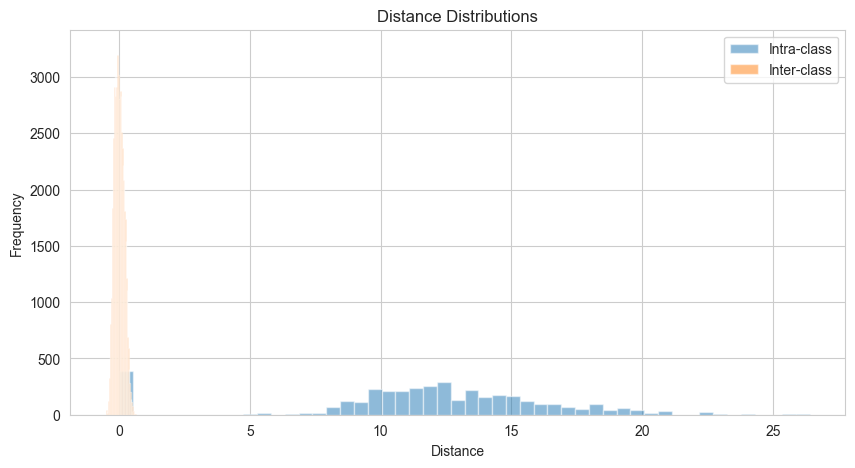

In [8]:
from collections import defaultdict
from itertools import combinations
import torch.nn.functional as F

# Set model to evaluation mode
net.eval()

# Collect embeddings and labels from validation set
all_embeddings = []
all_labels = []

with torch.no_grad():
    for img0, img1, _, label0, label1 in test_dataloader:
        img0, img1 = img0.to(DEVICE), img1.to(DEVICE)
        label0, label1 = label0.to(DEVICE), label1.to(DEVICE)
        output1, output2 = net(img0, img1)

        all_embeddings.append(torch.cat([output1, output2]))
        all_labels.append(torch.cat([label0, label1]))

# Concatenate all embeddings and labels
all_embeddings = torch.cat(all_embeddings)  # shape: [N, D]
all_labels = torch.cat(all_labels)          # shape: [N]

# Group embeddings by class
class_to_embeddings = defaultdict(list)
for emb, label in zip(all_embeddings, all_labels):
    class_to_embeddings[label.item()].append(emb)

for key in class_to_embeddings:
    class_to_embeddings[key] = torch.stack(class_to_embeddings[key])

# Compute intra-class distances
intra_dists = []
for emb_list in class_to_embeddings.values():
    for i, j in combinations(range(len(emb_list)), 2):
        dist = F.pairwise_distance(emb_list[i].unsqueeze(0), emb_list[j].unsqueeze(0))
        #dist = F.cosine_similarity(emb_list[i].unsqueeze(0), emb_list[j].unsqueeze(0))
        intra_dists.append(dist.item())

# Compute inter-class distances
inter_dists = []
label_keys = list(class_to_embeddings.keys())
for i in range(len(label_keys)):
    for j in range(i+1, len(label_keys)):
        emb_i = class_to_embeddings[label_keys[i]]
        emb_j = class_to_embeddings[label_keys[j]]
        for e1 in emb_i:
            for e2 in emb_j:
                dist = F.cosine_similarity(e1.unsqueeze(0), e2.unsqueeze(0))
                inter_dists.append(dist.item())

# Compute statistics
avg_intra = sum(intra_dists) / len(intra_dists)
avg_inter = sum(inter_dists) / len(inter_dists)

print(f"✅ Average Intra-Class Distance: {avg_intra:.4f}")
print(f"✅ Average Inter-Class Distance: {avg_inter:.4f}")

# Optional: Visualize distributions
plt.figure(figsize=(10, 5))
plt.hist(intra_dists, bins=50, alpha=0.5, label='Intra-class')
plt.hist(inter_dists, bins=50, alpha=0.5, label='Inter-class')
plt.title("Distance Distributions")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


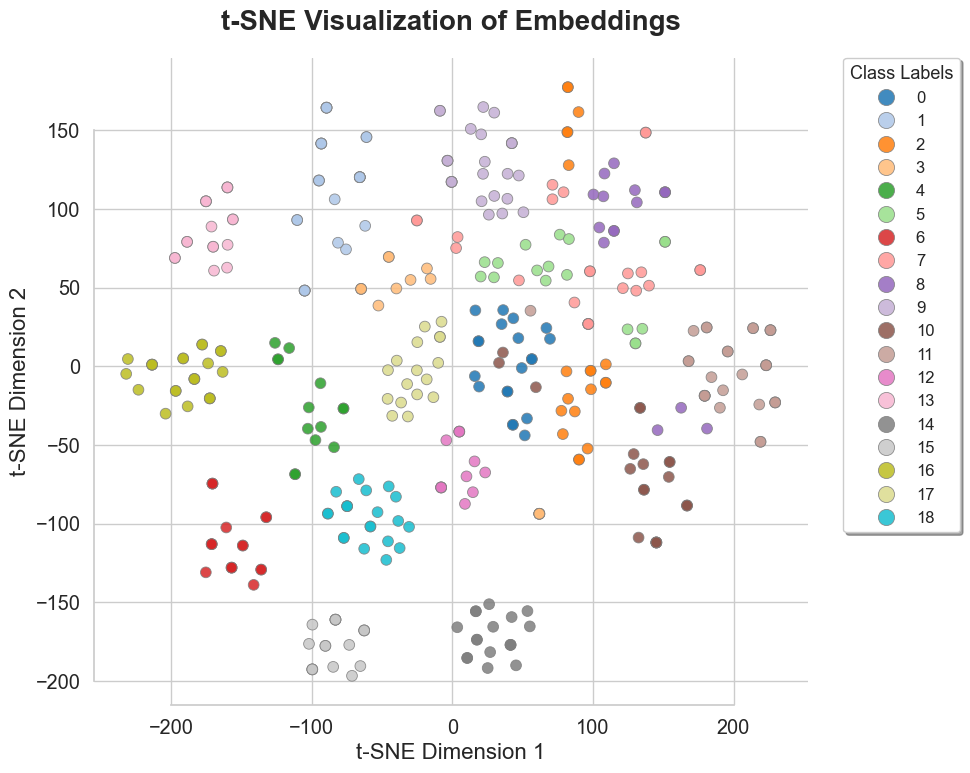

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns

# Convert tensors to NumPy arrays
X = all_embeddings.cpu().numpy()
y = all_labels.cpu().numpy()

# Run t-SNE
tsne = TSNE(n_components=2, max_iter=1000, random_state=42, metric="euclidean")
X_tsne = tsne.fit_transform(X)

# Prepare the figure
plt.figure(figsize=(10, 8))
sns.set(style="whitegrid", font_scale=1.3)

# Generate a distinct color palette based on number of classes
num_classes = len(np.unique(y))
palette = sns.color_palette("tab20", num_classes) if num_classes <= 20 else sns.color_palette("husl", num_classes)

# Scatter plot with clean styling
scatter = sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=y,
    palette=palette,
    legend='full',
    s=60,             # bigger markers for visibility
    edgecolor='gray',  # subtle border around points for clarity
    alpha=0.85        # slight transparency for overlap clarity
)

# Title and labels
plt.title("t-SNE Visualization of Embeddings", fontsize=20, weight='bold', pad=20)
plt.xlabel("t-SNE Dimension 1", fontsize=16)
plt.ylabel("t-SNE Dimension 2", fontsize=16)

# Legend outside plot on the right, with larger markers
plt.legend(
    title="Class Labels",
    title_fontsize='13',
    fontsize='12',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0,
    markerscale=1.5,
    frameon=True,
    shadow=True
)

# Remove top and right spines for a cleaner look
sns.despine(trim=True)

# Tight layout to use space well
plt.tight_layout()

plt.show()


In [10]:
def plot_evaluation_metrics(metrics_dict):
    """Plot evaluation metrics and confusion matrix in separate subplots."""
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Plot scalar metrics
    scalar_metrics = ['accuracy', 'precision', 'recall', 'f1_score', 'avg_distance']
    scalar_values = [metrics_dict[k] for k in scalar_metrics]
    
    axs[0].bar(scalar_metrics, scalar_values, color='skyblue')
    axs[0].set_title("Evaluation Metrics")
    axs[0].set_ylim([0, 1])
    axs[0].tick_params(axis='x', rotation=45)
    for i, v in enumerate(scalar_values):
        axs[0].text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=9)

    # Plot confusion matrix
    cm = metrics_dict['confusion_matrix']
    cm_matrix = np.array([
        [cm['TP'], cm['FP']],
        [cm['FN'], cm['TN']]
    ])
    
    im = axs[1].imshow(cm_matrix, cmap='Blues')
    axs[1].set_title("Confusion Matrix")
    axs[1].set_xticks([0, 1])
    axs[1].set_yticks([0, 1])
    axs[1].set_xticklabels(['Predicted Similar', 'Predicted Dissimilar'])
    axs[1].set_yticklabels(['Actual Similar', 'Actual Dissimilar'])
    
    # Annotate confusion matrix
    for i in range(2):
        for j in range(2):
            axs[1].text(j, i, str(cm_matrix[i, j]), ha='center', va='center', color='black', fontsize=12)

    plt.tight_layout()
    plt.show()



Evaluation Metrics:
Accuracy: 0.7211
Precision: 1.0000
Recall: 0.4854
F1 Score: 0.6536
Avg Distance: 0.2671


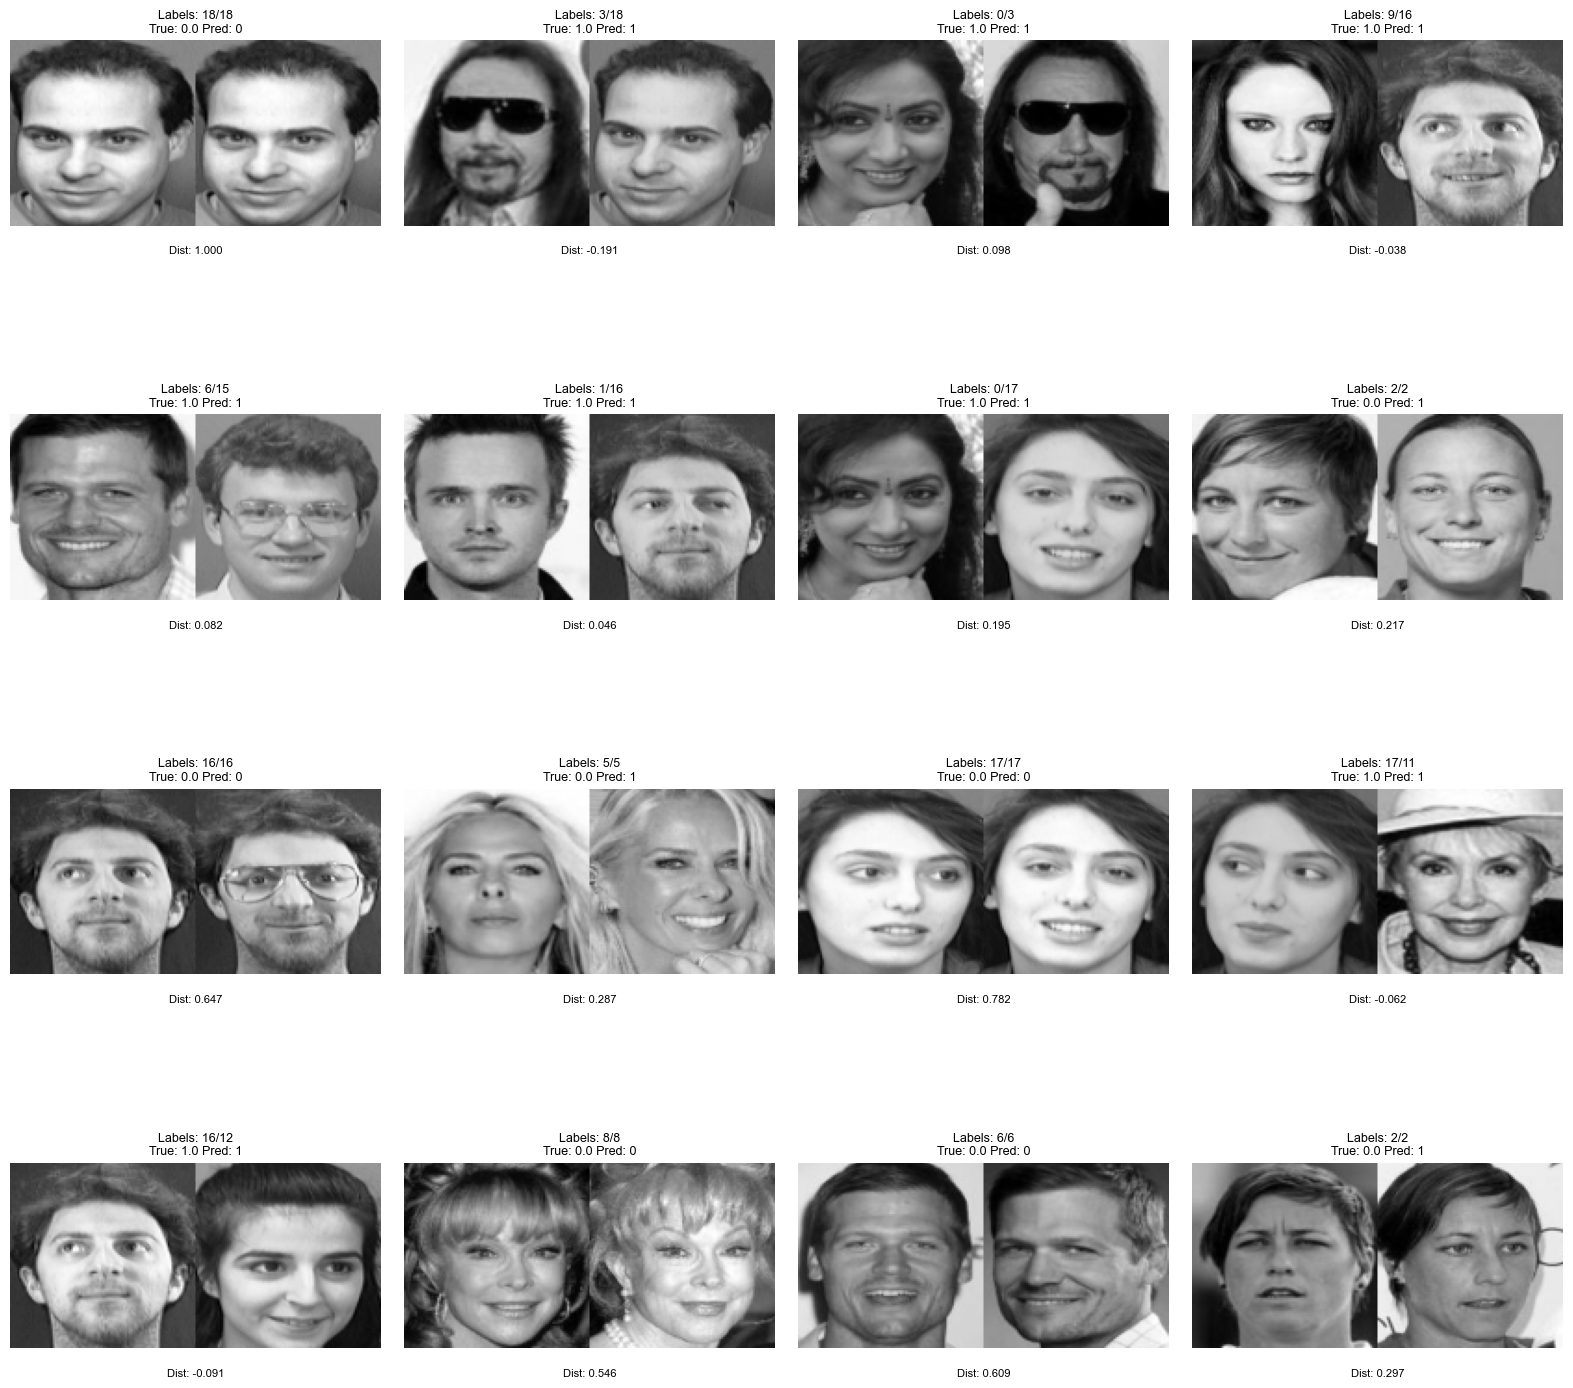

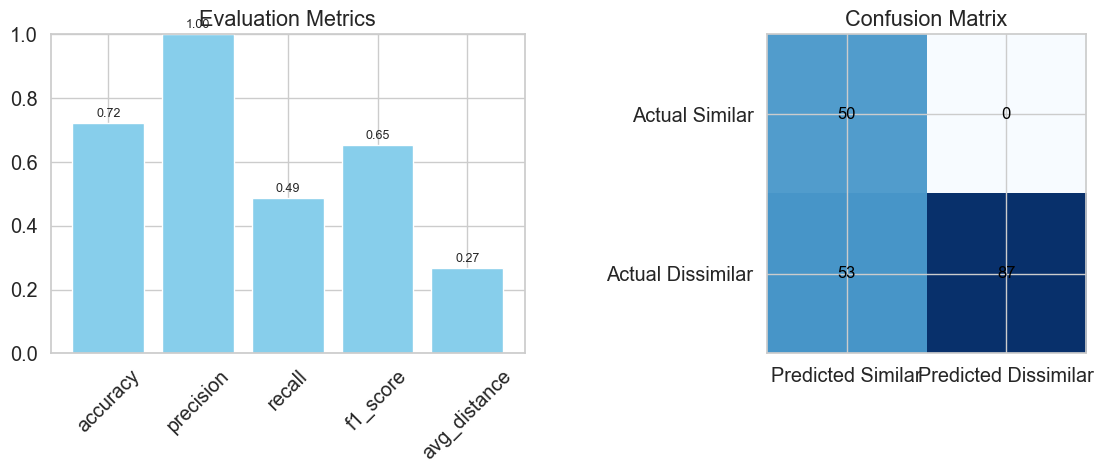

In [11]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
g.manual_seed(42)

def process_label(lbl):
    """Helper function to extract label value from various formats"""
    if isinstance(lbl, torch.Tensor):
        return lbl.item() if lbl.numel() == 1 else lbl[0].item()
    elif isinstance(lbl, (list, np.ndarray)):
        return lbl[0] if len(lbl) > 0 else lbl
    return lbl

def get_embeddings(model, img1, img2):
    """Get embeddings from the model for both images"""
    with torch.no_grad():
        model.eval()
        emb1, emb2 = model(img1, img2)
    return emb1, emb2

def evaluate_siamese_model(model, dataloader, distance_threshold=0.5):
    """Calculate comprehensive metrics using only Euclidean distance"""
    model.eval()
    
    # Initialize counters
    total_samples = 0
    true_positives = 0
    false_positives = 0
    true_negatives = 0
    false_negatives = 0
    distances = []
    
    with torch.no_grad():
        for img1, img2, label, _, _ in dataloader:
            img1, img2, label = img1.to(DEVICE), img2.to(DEVICE), label.to(DEVICE)
            
            # Get embeddings and distances
            emb1, emb2 = model(img1, img2)
            
            # Convert to numpy
            euclidean_dist = F.cosine_similarity(emb1, emb2).cpu().numpy()
            labels = label.cpu().numpy()
            
            # Update metrics
            for i in range(len(labels)):
                total_samples += 1
                pred = 0 if euclidean_dist[i] >= distance_threshold else 1
                true_label = labels[i]
                
                if pred == 0 and true_label == 0:
                    true_positives += 1
                elif pred == 0 and true_label == 1:
                    false_positives += 1
                elif pred == 1 and true_label == 1:
                    true_negatives += 1
                else:
                    false_negatives += 1
                
                distances.append(euclidean_dist[i])
    
    # Calculate metrics
    accuracy = (true_positives + true_negatives) / total_samples
    precision = true_positives / (true_positives + false_positives + 1e-10)
    recall = true_positives / (true_positives + false_negatives + 1e-10)
    f1_score = 2 * (precision * recall) / (precision + recall + 1e-10)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score,
        'avg_distance': np.mean(distances),
        'confusion_matrix': {
            'TP': true_positives,
            'FP': false_positives,
            'TN': true_negatives,
            'FN': false_negatives
        }
    }

def plot_samples_with_metrics(test_loader, model, n_samples=8, n_cols=4, distance_threshold=0.5):
    """Visualize sample pairs with distance metrics"""
    pairs_imgs = []
    
    for _ in range(n_samples):
        img1, img2, label, label1, label2 = next(iter(test_loader))
        lbl1 = process_label(label1)
        lbl2 = process_label(label2)
        true_label = process_label(label)

        # Get embeddings and distance
        emb1, emb2 = get_embeddings(model, img1.to(DEVICE), img2.to(DEVICE))
        euclid = F.cosine_similarity(emb1, emb2).mean().item()
        pred = 0 if euclid >= distance_threshold else 1
        
        # Prepare image
        img1_gray = img1[0].cpu().mean(dim=0, keepdim=True)
        img2_gray = img2[0].cpu().mean(dim=0, keepdim=True)
        concat_img = torch.cat((img1_gray, img2_gray), dim=2)
        
        pairs_imgs.append((
            concat_img.squeeze(0), 
            lbl1, lbl2, 
            euclid,
            true_label, pred
        ))

    # Create figure
    n_rows = (n_samples + n_cols - 1) // n_cols
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    if n_samples > 1:
        axs = axs.flatten()
    else:
        axs = [axs]

    for i, ax in enumerate(axs):
        if i < n_samples:
            img, lbl1, lbl2, euclid, true_label, pred = pairs_imgs[i]
            
            # Display image
            ax.imshow(img.numpy(), cmap='gray')
            ax.axis('off')
            
            # Prediction correctness
            #correct = "✓" if pred == true_label else "✗"
            #title_color = "green" if correct == "✓" else "red"
            
            ax.set_title(f"Labels: {lbl1}/{lbl2}\nTrue: {true_label} Pred: {pred}", 
                        fontsize=9, color="black")

            # Distance info
            #dist_color = "green" if euclid <= distance_threshold else "red"
            ax.text(0.5, -0.15, f"Dist: {euclid:.3f}", 
                   transform=ax.transAxes, ha='center', fontsize=8, color="black")
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# Example usage
if __name__ == "__main__":
    # Calculate metrics
    metrics = evaluate_siamese_model(net, test_dataloader)
    print("\nEvaluation Metrics:")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1 Score: {metrics['f1_score']:.4f}")
    print(f"Avg Distance: {metrics['avg_distance']:.4f}")
    
    # Visualize samples
    plot_samples_with_metrics(test_dataloader, net, n_samples= 16, distance_threshold=0.5)
    plot_evaluation_metrics(metrics)

# Test 1 Matrix with Threshold

C:\Users\ehait\AppData\Local\Temp\ipykernel_4300\2034304316.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  winter   = plt.cm.get_cmap("winter", 256)          # default blue→green


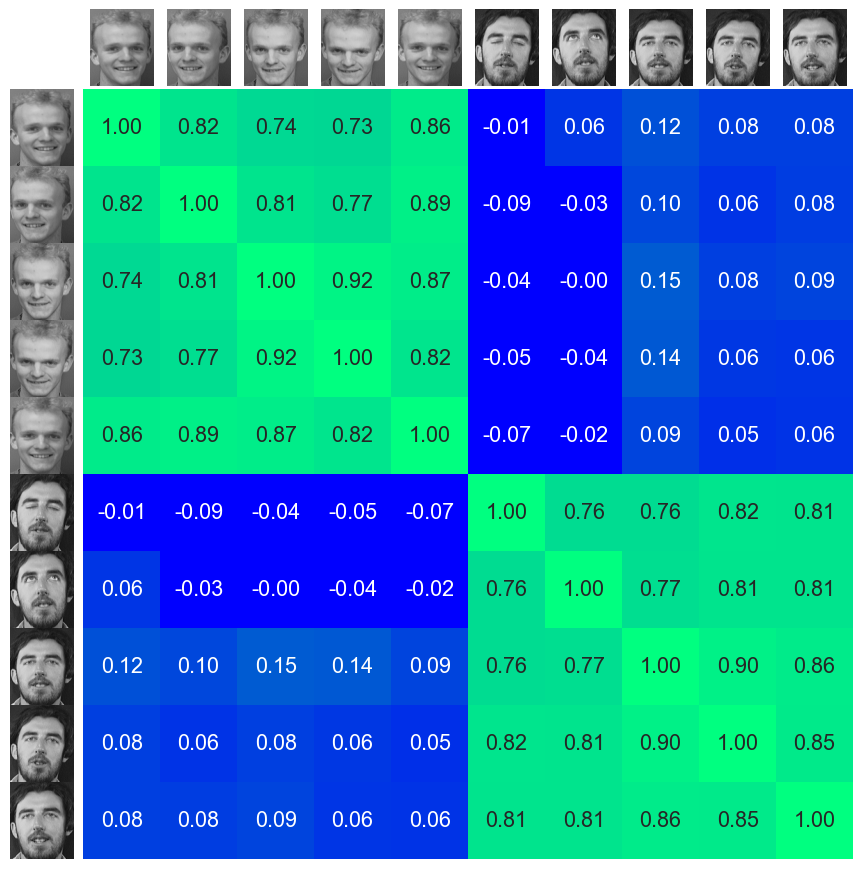

In [43]:
# =============================================================================
# 10 × 10 Similarity Matrix – custom blue→green colormap
# • 2 random classes, 5 images each
# • intra-class mean ≥ 0.60  and  inter-class mean ≤ 0.40  (otherwise best fallback)
# • Thumbnails exactly the size of a heat-map cell (top & left)
# • NO title, NO color bar
#
# Assumes the following objects already exist in the notebook:
#   net, transformation_test, folder_dataset_test, DEVICE
# =============================================================================

import random, numpy as np, torch, torch.nn.functional as F
import matplotlib.pyplot as plt, seaborn as sns
import matplotlib.colors as mcolors
from PIL import Image
from collections import defaultdict

# -----------------------------------------------------------------------------
# 0) Custom colormap (gamma < 1 → brighter low values, more contrast)
# -----------------------------------------------------------------------------
winter   = plt.cm.get_cmap("winter", 256)          # default blue→green
gamma    = 0.55                                    # brighten dark region
colors   = winter(np.linspace(0, 1, 256) ** gamma)
blue2grn = mcolors.ListedColormap(colors)

# -----------------------------------------------------------------------------
# Helper 1 – cosine-similarity matrix
# -----------------------------------------------------------------------------
def cosine_sim_matrix(emb):
    """Return (n×n) cosine-similarity matrix with 1.0 on the diagonal."""
    emb = F.normalize(emb, p=2, dim=1)
    sim = emb @ emb.T
    sim.fill_diagonal_(1.0)
    return sim.cpu().numpy()

# -----------------------------------------------------------------------------
# Helper 2 – attach thumbnails flush to the heat-map cells
# -----------------------------------------------------------------------------
def add_thumbnails(ax, images, side="left", pad=0.003):
    """
    side='left' → row thumbnails
    side='top'  → column thumbnails
    Must be called AFTER fig.canvas.draw().
    """
    fig, n  = ax.figure, len(images)
    axpos   = ax.get_position()
    cell    = (axpos.height if side == "left" else axpos.width) / n

    for idx, img in enumerate(images):
        if side == "left":                          # rows
            x0 = axpos.x0 - pad - cell
            y0 = axpos.y0 + axpos.height - (idx + 1) * cell
        else:                                       # columns
            x0 = axpos.x0 + idx * cell
            y0 = axpos.y1 + pad
        thumb_ax = fig.add_axes([x0, y0, cell, cell])
        thumb_ax.imshow(np.asarray(img)); thumb_ax.axis("off")

# -----------------------------------------------------------------------------
# 1) Collect image paths per class (need ≥5 images each)
# -----------------------------------------------------------------------------
cls2paths = defaultdict(list)
for path, lbl in folder_dataset_test.imgs:
    cls2paths[lbl].append(path)

valid_classes = [c for c, lst in cls2paths.items() if len(lst) >= 5]
assert len(valid_classes) >= 2, "Need at least two classes with ≥5 images each!"

# -----------------------------------------------------------------------------
# 2) Random class-pair with threshold check (intra ≥ 0.60, inter ≤ 0.40)
# -----------------------------------------------------------------------------
def sample_with_thresholds(intra_thr=0.60, inter_thr=0.40, trials=100):
    best_imgs, best_sim, best_gap = None, None, -1
    for _ in range(trials):
        c1, c2 = random.sample(valid_classes, 2)
        paths  = random.sample(cls2paths[c1], 5) + random.sample(cls2paths[c2], 5)
        imgs   = [Image.open(p).convert("RGB") for p in paths]

        net.eval()
        with torch.no_grad():
            batch = torch.stack([transformation_test(im) for im in imgs]).to(DEVICE)
            emb   = net.forward_once(batch).cpu()

        sim    = cosine_sim_matrix(emb)
        intra1 = sim[:5, :5][np.triu_indices(5, 1)].mean()
        intra2 = sim[5:, 5:][np.triu_indices(5, 1)].mean()
        inter  = sim[:5, 5:].mean()
        gap    = (intra1 + intra2) / 2 - inter

        if intra1 >= intra_thr and intra2 >= intra_thr and inter <= inter_thr:
            return imgs, sim                         # thresholds satisfied
        if gap > best_gap:                           # remember best attempt
            best_imgs, best_sim, best_gap = imgs, sim, gap
    return best_imgs, best_sim                       # fallback after trials

pil_imgs, sim_mat = sample_with_thresholds()

# -----------------------------------------------------------------------------
# 3) Plot heat-map (no title) + thumbnails
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(10, 10))
ax  = sns.heatmap(sim_mat,
                 cmap=blue2grn,
                 vmin=0, vmax=1,
                 square=True,
                 annot=True, fmt=".2f",
                 cbar=False,
                 xticklabels=False, yticklabels=False)

fig.canvas.draw()                 # finalize axis position
add_thumbnails(ax, pil_imgs, side="left")
add_thumbnails(ax, pil_imgs, side="top")
plt.show()

# Test 2 Matrix without Threshold

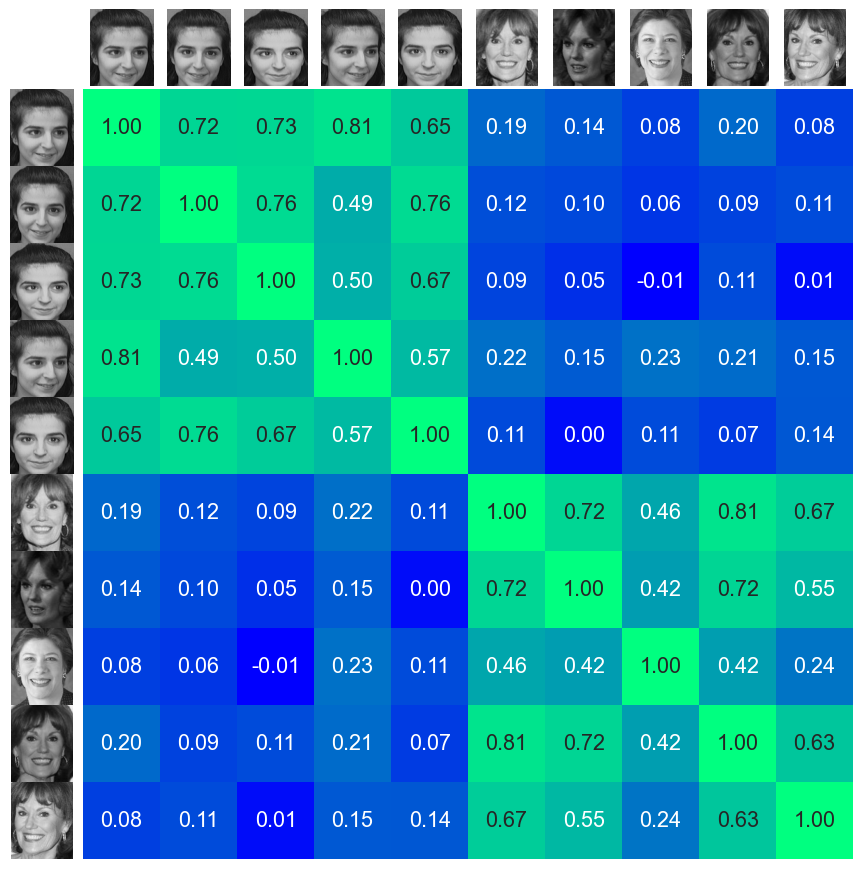

In [18]:
# =============================================================================
# 10 × 10 similarity matrix (blue → green) for a MS-Loss Siamese model
# – random 5 + 5 images from two classes (no thresholds → honest snapshot)
# – thumbnails exactly cell-sized on top & left
# – ready to swap in any other model: just change MODEL = <your_model>
# =============================================================================
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="torchvision")

import random
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from PIL import Image
from collections import defaultdict

# -----------------------------------------------------------------------------
# 0) Load your MS-Loss model  (replace path if necessary)
# -----------------------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

net = SiameseNetwork().to(DEVICE)
net.load_state_dict(torch.load("models_ms2/best_model_overall.pt",
                               map_location=DEVICE))

MODEL = net            # ← the visualisation below will use this model

# -----------------------------------------------------------------------------
# 1) (optional) reproducible randomness
# -----------------------------------------------------------------------------
random.seed(41)
np.random.seed(41)
torch.manual_seed(41)
torch.cuda.manual_seed_all(41)

# -----------------------------------------------------------------------------
# 2) build a gamma-corrected blue→green colormap
# -----------------------------------------------------------------------------
orig_cmap  = plt.colormaps.get_cmap("winter")        # avoids deprecation
gamma      = 0.55                                    # <1 = brighter low values
colors      = orig_cmap(np.linspace(0, 1, 256) ** gamma)
blue2green  = mcolors.ListedColormap(colors)

# -----------------------------------------------------------------------------
# 3) helper functions
# -----------------------------------------------------------------------------
def cosine_similarity_matrix(emb: torch.Tensor) -> np.ndarray:
    """(n × d) → (n × n) cosine-similarity matrix with 1.0 on the diagonal."""
    emb = F.normalize(emb, p=2, dim=1)
    sim = emb @ emb.T
    sim.fill_diagonal_(1.0)
    return sim.cpu().numpy()

def add_thumbnails(ax, images, side="left", pad=0.003):
    """
    Place thumbnails flush with the heat-map cells.
    Call AFTER fig.canvas.draw(); otherwise positions may shift.
    side='left' → row thumbnails,  side='top' → column thumbnails
    """
    fig, n     = ax.figure, len(images)
    axpos      = ax.get_position()
    cell_size  = (axpos.height if side == "left" else axpos.width) / n

    for i, img in enumerate(images):
        if side == "left":                                        # rows
            x0 = axpos.x0 - pad - cell_size
            y0 = axpos.y0 + axpos.height - (i + 1) * cell_size
        else:                                                     # columns
            x0 = axpos.x0 + i * cell_size
            y0 = axpos.y1 + pad
        thumb = fig.add_axes([x0, y0, cell_size, cell_size])
        thumb.imshow(np.asarray(img))
        thumb.axis("off")

# -----------------------------------------------------------------------------
# 4) collect at least 5 images per class
# -----------------------------------------------------------------------------
cls2paths = defaultdict(list)
for path, lbl in folder_dataset_test.imgs:
    cls2paths[lbl].append(path)

valid_classes = [c for c, lst in cls2paths.items() if len(lst) >= 5]
assert len(valid_classes) >= 2, "Need ≥2 classes with ≥5 images each!"

# -----------------------------------------------------------------------------
# 5) sample two classes, take 5 images from each (no thresholds)
# -----------------------------------------------------------------------------
cls_a, cls_b = random.sample(valid_classes, 2)
paths        = random.sample(cls2paths[cls_a], 5) + \
               random.sample(cls2paths[cls_b], 5)
pil_images   = [Image.open(p).convert("RGB") for p in paths]

# -----------------------------------------------------------------------------
# 6) compute embeddings & similarity matrix
# -----------------------------------------------------------------------------
MODEL.eval()
with torch.no_grad():
    batch = torch.stack([transformation_test(im) for im in pil_images]).to(DEVICE)
    embeddings = MODEL.forward_once(batch).cpu()           # (10, D)

sim_matrix = cosine_similarity_matrix(embeddings)

# -----------------------------------------------------------------------------
# 7) plot heat-map + thumbnails
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(10, 10))
ax  = sns.heatmap(sim_matrix,
                  cmap=blue2green,
                  vmin=0, vmax=1,
                  square=True,
                  annot=True, fmt=".2f",
                  cbar=False,
                  xticklabels=False, yticklabels=False)

fig.canvas.draw()
add_thumbnails(ax, pil_images, side="left")
add_thumbnails(ax, pil_images, side="top")
plt.show()

# Test Statistik 1

In [ ]:
# -----------------------------------------------------------------------------
# 0) Load your Loss model  (replace path if necessary)
# -----------------------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

net = SiameseNetwork().to(DEVICE)
net.load_state_dict(torch.load("models_ms2/best_model_overall.pt",
                               map_location=DEVICE))

net1 = SiameseNetwork().to(DEVICE)
net1.load_state_dict(torch.load("models_ms2/best_model_fold_1.pt",
                               map_location=DEVICE))


Confusion Matrix – MS-Loss  (thr=0.363)
 [[74 16]
 [ 2 98]]

Confusion Matrix – MS-Loss Fold 1  (thr=0.244)
 [[83 14]
 [ 8 85]]


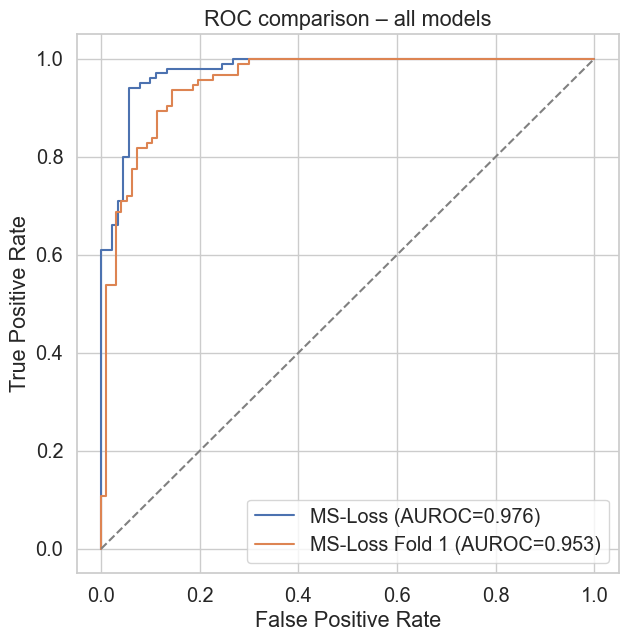

,accuracy,precision,recall,F1,AUROC,AUPRC,opt_threshold
model,,,,,,,
MS-Loss,0.905,0.860,0.980,0.916,0.976,0.977,0.363
MS-Loss Fold 1,0.884,0.859,0.914,0.885,0.953,0.938,0.244


In [36]:
# =============================================================================
# 0) Imports
# =============================================================================
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

import torch, torch.nn.functional as F
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc, average_precision_score,
    precision_recall_curve, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)

# -----------------------------------------------------------------------------
# 1) Helper: collect similarity scores & labels for a Siamese model
# -----------------------------------------------------------------------------
def collect_scores(model, dataloader, device, sim='cosine'):
    """
    Returns
        scores : np.array, shape (N,)  – similarity (larger = more similar)
        labels : np.array, shape (N,)  – 0 (similar) / 1 (dissimilar)
    """
    model.eval()
    scores, labels = [], []

    with torch.no_grad():
        for img1, img2, lbl, *_ in dataloader:
            img1, img2 = img1.to(device), img2.to(device)
            emb1, emb2 = model(img1, img2)

            if sim == 'cosine':
                s = F.cosine_similarity(emb1, emb2)          # higher = similar
            elif sim == 'euclidean':
                s = -F.pairwise_distance(emb1, emb2)         # negate → higher = similar
            else:
                raise ValueError("sim must be 'cosine' or 'euclidean'")

            scores.extend(s.cpu().numpy())
            labels.extend(lbl.view(-1).cpu().numpy())        # 0 = similar, 1 = dissimilar

    return np.array(scores), np.array(labels)

# -----------------------------------------------------------------------------
# 2) Helper: compute scalar metrics at a chosen threshold
# -----------------------------------------------------------------------------
def metrics_at_threshold(scores, labels, thr):
    preds = (scores < thr)  # our labels: 0 = similar → want high score; dissimilar → low
    acc   = accuracy_score(labels, preds)
    prec  = precision_score(labels, preds)
    rec   = recall_score(labels, preds)
    f1    = f1_score(labels, preds)
    return acc, prec, rec, f1

# -----------------------------------------------------------------------------
# 3) Main evaluation function
# -----------------------------------------------------------------------------
def evaluate_models(model_dict, dataloader, device):
    """
    model_dict : {name: model_object}
    Returns a DataFrame with metrics and draws a ROC-curve figure.
    """
    table_rows = []
    plt.figure(figsize=(7,7))

    for name, model in model_dict.items():
        scores, labels = collect_scores(model, dataloader, device)

        # ROC metrics
        fpr, tpr, roc_thr = roc_curve(labels, -scores)       # invert ⇒ pos-class = dissimilar
        auroc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUROC={auroc:.3f})")

        # PR metrics
        ap_score = average_precision_score(labels, -scores)

        # pick threshold that maximises F1 on validation scores
        # (or choose 0.5 quantile, etc. – your choice)
        f1s = []
        for thr in roc_thr:
            _, _, _, f1 = metrics_at_threshold(scores, labels, thr)
            f1s.append(f1)
        best_thr = roc_thr[np.argmax(f1s)]

        acc, prec, rec, f1 = metrics_at_threshold(scores, labels, best_thr)

        table_rows.append({
            'model': name,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'F1': f1,
            'AUROC': auroc,
            'AUPRC': ap_score,
            'opt_threshold': float(best_thr)
        })

        # optional: per-model confusion matrix
        cm = confusion_matrix(labels, (scores < best_thr))
        print(f"\nConfusion Matrix – {name}  (thr={best_thr:.3f})\n", cm)

    # finish ROC plot
    plt.plot([0,1],[0,1],'--',color='gray')
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC comparison – all models"); plt.legend(); plt.grid(True)
    plt.show()

    return pd.DataFrame(table_rows).set_index('model').round(3)

# =============================================================================
# 4) Example usage
# =============================================================================

# 4-A ) load/instantiate the other models you want to compare
#  ---------------------------------------------------------
# net_ms   = ...  # already loaded ("best_model_overall.pt")
# net_con  = ...  # contrastive-loss model
# net_trip = ...  # triplet-loss model
# (make sure all inherit the same SiameseNetwork forward API)

# 4-B ) put them in a dict  {name: model}
models_to_compare = {
    'MS-Loss'   : net, # already loaded above
    'MS-Loss Fold 1' : net1
    # 'Contrastive': net_con,
    # 'Triplet'    : net_trip,
}

# 4-C ) run evaluation
results_df = evaluate_models(models_to_compare, test_dataloader, DEVICE)

# 4-D ) inspect metrics table
display(results_df)

# Test Statistik 2

accuracy        precision        recall            F1         \
                   mean    std      mean    std   mean    std   mean    std   
model                                                                         
MS-Loss           0.859  0.037     0.799  0.061  0.966  0.032  0.873  0.031   
MS-Loss Fold 1    0.856  0.030     0.800  0.059  0.948  0.047  0.865  0.028   

                AUROC         AUPRC        opt_threshold        fold         
                 mean    std   mean    std          mean    std mean    std  
model                                                                        
MS-Loss         0.955  0.014  0.949  0.017         0.359  0.077  9.5  5.916  
MS-Loss Fold 1  0.960  0.011  0.957  0.016         0.318  0.071  9.5  5.916


Confusion Matrix – MS-Loss (thr=0.311)
 [[80 12]
 [ 7 91]]

Confusion Matrix – MS-Loss Fold 1 (thr=0.274)
 [[82 21]
 [ 9 78]]


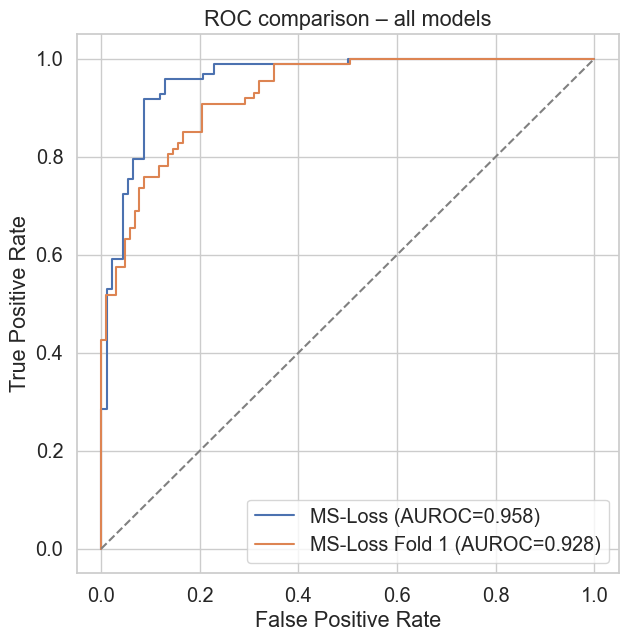

Wilcoxon AUROC  MS-Loss vs. MS-Loss Fold 1:  p = 0.3799


In [46]:
# =============================================================================
# 0) Imports
# =============================================================================
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

from scipy.stats import wilcoxon
import torch, torch.nn.functional as F
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import (
    roc_curve, auc, average_precision_score,
    confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score
)

# -----------------------------------------------------------------------------
# 1) Collect similarity scores and labels for a Siamese model
# -----------------------------------------------------------------------------
def collect_scores(model, dataloader, device, sim='cosine'):
    model.eval()
    scores, labels = [], []
    with torch.no_grad():
        for img1, img2, lbl, *_ in dataloader:
            img1, img2 = img1.to(device), img2.to(device)
            e1, e2 = model(img1, img2)
            s = (F.cosine_similarity(e1, e2) if sim == 'cosine'
                 else -F.pairwise_distance(e1, e2))          # negate: higher = more similar
            scores.extend(s.cpu().numpy())
            labels.extend(lbl.view(-1).cpu().numpy())        # 0 = similar, 1 = dissimilar
    return np.asarray(scores), np.asarray(labels)

# -----------------------------------------------------------------------------
# 2) Compute scalar metrics at a given threshold
# -----------------------------------------------------------------------------
def metrics_at_threshold(scores, labels, thr):
    preds = (scores < thr)                                   # 1 = dissimilar
    return (
        accuracy_score(labels, preds),
        precision_score(labels, preds, zero_division=0),
        recall_score(labels, preds,    zero_division=0),
        f1_score(labels, preds,        zero_division=0)
    )

# -----------------------------------------------------------------------------
# 3) Evaluation function (flags to mute plots/CMs)
# -----------------------------------------------------------------------------
def evaluate_models(model_dict, dataloader, device,
                    show_plot=True, show_cm=True):
    rows = []
    if show_plot:
        plt.figure(figsize=(7, 7))

    for name, model in model_dict.items():
        scores, labels = collect_scores(model, dataloader, device)

        # ROC curve
        fpr, tpr, thr = roc_curve(labels, -scores)
        if show_plot:
            plt.plot(fpr, tpr, label=f"{name} (AUROC={auc(fpr, tpr):.3f})")

        # Best-F1 threshold
        f1s      = [metrics_at_threshold(scores, labels, t)[-1] for t in thr]
        best_thr = thr[int(np.nanargmax(f1s))]
        acc, prec, rec, f1 = metrics_at_threshold(scores, labels, best_thr)

        rows.append({
            'model': name, 'accuracy': acc, 'precision': prec, 'recall': rec,
            'F1': f1, 'AUROC': auc(fpr, tpr),
            'AUPRC': average_precision_score(labels, -scores),
            'opt_threshold': float(best_thr)
        })

        if show_cm:
            cm = confusion_matrix(labels, (scores < best_thr))
            print(f"\nConfusion Matrix – {name} (thr={best_thr:.3f})\n", cm)

    if show_plot:
        plt.plot([0, 1], [0, 1], '--', color='gray')
        plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
        plt.title("ROC comparison – all models"); plt.legend(); plt.grid(True)
        plt.show()

    return pd.DataFrame(rows).set_index('model').round(3)

# -----------------------------------------------------------------------------
# 4) Models to compare
# -----------------------------------------------------------------------------
models_to_compare = {
    'MS-Loss'        : net,
    'MS-Loss Fold 1' : net1,
    # 'Triplet'      : net_trip,
}

# -----------------------------------------------------------------------------
# 5) Cross-validation / multi-seed loop (silent evaluation)
# -----------------------------------------------------------------------------
#fold_seeds = [11, 22, 33, 44, 55]
fold_seeds = list(range(20))
fold_results = []

for seed in fold_seeds:
    g = torch.Generator().manual_seed(seed)
    fixed_loader = DataLoader(test_dataset, batch_size=1,
                              shuffle=False, num_workers=0, generator=g)
    one_fold = evaluate_models(models_to_compare, fixed_loader,
                               DEVICE, show_plot=False, show_cm=False)
    one_fold['fold'] = seed
    fold_results.append(one_fold)

cv_results = pd.concat(fold_results)

# Display mean ± std across folds
summary = (cv_results.reset_index()
           .groupby('model')
           .agg(['mean', 'std'])
           .round(3))
display(summary)

# -----------------------------------------------------------------------------
# 6) Show ROC + confusion matrices once (first seed)
# -----------------------------------------------------------------------------
evaluate_models(models_to_compare, fixed_loader,
                DEVICE, show_plot=True, show_cm=True)

# -----------------------------------------------------------------------------
# 7) Wilcoxon test: AUROC  MS-Loss  vs.  MS-Loss Fold 1
# -----------------------------------------------------------------------------
if {'MS-Loss', 'MS-Loss Fold 1'}.issubset(cv_results.index.get_level_values(0)):
    ms_base = cv_results.loc['MS-Loss',        'AUROC']
    ms_fold = cv_results.loc['MS-Loss Fold 1', 'AUROC']
    stat, p = wilcoxon(ms_base.values, ms_fold.values)
    print(f"Wilcoxon AUROC  MS-Loss vs. MS-Loss Fold 1:  p = {p:.4f}")
else:
    print("Wilcoxon skipped – required keys missing.")
